In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import GComputation  # 0.4.0: Margins -> GComputation

rng = np.random.default_rng(7)
n = 4000
df = pd.DataFrame({
    "exposure": rng.uniform(1, 5, n),
    "treated": rng.binomial(1, 0.4, n),
    "age": rng.integers(20, 75, n),
})
lp = -2.0 + 0.6 * df["treated"] + 0.02 * df["age"]
df["events"] = rng.poisson(df["exposure"] * np.exp(lp))

fit = smf.glm(
    "events ~ treated + age",
    data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["exposure"]),
).fit()

In [2]:
m = GComputation(fit, vcov="HC1", at="overall", scale="log")
print(m.contrasts(
    scenarios=[
        {"atexog": {"treated": 1}, "label": "treated"},
        {"atexog": {"treated": 0}, "label": "control"},
    ],
    contrasts=[+1, -1],
).summary())

              Graph Result (delta, level=0.95)              
         estimate  std err        z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
treated    1.8059   0.0289  20.4205  0.000    1.7063, 1.9113

n = 4000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 0.076%
plan d2fda47@1 | κ = 0.000


In [3]:
print(m.predict(atexog={"age": [25, 45, 65]}).summary())

              Graph Result (delta, level=0.95)              
        estimate  std err         z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
age=25    0.3050   0.0287  -41.3657  0.000    0.2883, 0.3227
age=45    0.4531   0.0157  -50.3486  0.000    0.4394, 0.4673
age=65    0.6731   0.0192  -20.5771  0.000    0.6482, 0.6990

n = 4000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 0.243%
plan d2fda47@1 | κ = max 0.013


[Text(0.5, 0, 'Age'), Text(0, 0.5, 'Predicted event count')]

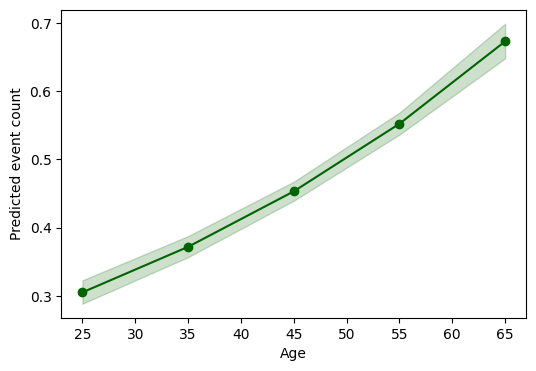

In [4]:
import matplotlib.pyplot as plt

res = m.predict(atexog={"age": [25, 35, 45, 55, 65]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_plot["age"], df_plot["estimate"], marker="o", color="darkgreen")
ax.fill_between(
    df_plot["age"], df_plot["ci_lower"], df_plot["ci_upper"],
    alpha=0.2, color="darkgreen"
)
ax.set(xlabel="Age", ylabel="Predicted event count")

In [5]:
print(GComputation(fit, at="overall", scale="identity").dydx("age").summary())

            Graph Result (delta, level=0.95)            
     estimate  std err        z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------
age    0.0099   0.0004  26.4099  0.000    0.0091, 0.0106

n = 4000
Delta-vs-sim disagreement: 1.214%
plan e9c5de4@1 | κ = 0.025
